# Headless Browsing & Selenium
**Topics:** Web crawling, dynamic (JS-rendered) pages, `selenium`, headless browser automation

**Note: Run this notebook locally, not in Colab.** It launches a real local browser
process. Headless mode *can* work in a hosted notebook, but it needs a browser + driver installed on that machine but hosted notebooks usually don't give you control over. A local Python environment (`uv`, Anaconda, `venv`, `conda`) is required for successful completion of this lab.

<!-- By the end of this notebook you will have a small crawler that:
1. Detects when a page needs a real browser to render (vs. plain HTML),
2. Drives a **headless** browser to load and interact with the page,
3. Waits robustly for content instead of guessing with `sleep`,
4. Extracts structured records (title, price, rating) into a `pandas.DataFrame`,
5. Follows pagination and product links (a tiny **crawl frontier**),
6. Saves the result to CSV, and
7. (Bonus) turns the crawled titles into a mini **inverted index**. -->


<!-- ## Motivation -->

A search engine's index is only as good as the **crawler** that feeds it. Modern retail, social
media, and dashboard sites render their content with JavaScript *after* the initial HTML arrives —
the raw HTML response is often just an empty `<div id="root"></div>`. If your crawler
only speaks HTTP + HTML (like `requests` + `BeautifulSoup`), it will index nothing. This lab is
about the "acquisition" stage of the IR pipeline: **getting the documents in the first place**,
before tokenization, indexing, or ranking can even begin.


## 0. Install packages

In [1]:
!uv add requests
!uv add bs4
!uv add selenium
!uv add pandas

Resolved 100 packages in 10ms
Checked 63 packages in 300ms
Resolved 100 packages in 9ms
Checked 63 packages in 315ms
Resolved 100 packages in 7ms
Checked 63 packages in 293ms
Resolved 100 packages in 8ms
Checked 63 packages in 350ms


In [2]:
!uv tree -d 1

Resolved 100 packages in 7ms
ir v0.1.0
├── bs4 v0.0.2
├── feedparser v6.0.14
├── ipykernel v7.3.0
├── nltk v3.10.3
├── pandas v2.3.3
├── requests v2.34.2
└── selenium v4.48.0


## 1. The problem: static fetch vs. rendered page

Let's repeat what first lab did: fetch a page with `requests` and parse it with
`BeautifulSoup`. We'll target a real product-listing page on **Yandex.Market** (a large Russian
e-commerce site). For our case, it is a real-world example of a JS-heavy web application.


In [1]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html",
    "Content-Type":"text/html; charset=utf-8"
}

In [2]:
import requests
from bs4 import BeautifulSoup

# url = "https://www.ozon.ru/category/smartfony-15502/"
# url = "https://www.wildberries.ru/catalog/elektronika/smartfony-i-telefony/vse-smartfony"
url = "https://market.yandex.ru/category/mobilnyye-telefony"
with requests.get(url, headers = headers) as response:
    print("Status:", response.status_code)
    print("Bytes received:", len(response.content))
    html = response.text
    dom = BeautifulSoup(html, 'html.parser')
    h1 = dom.select("h1")
    print([it.text for it in h1])

Status: 200
Bytes received: 2761401
['Мобильные телефоны']


In [3]:
import requests
from bs4 import BeautifulSoup

url = "https://www.ozon.ru/category/smartfony-15502/"
# url = "https://www.wildberries.ru/catalog/elektronika/smartfony-i-telefony/vse-smartfony"
# url = "https://market.yandex.ru/category/mobilnyye-telefony"
with requests.get(url, headers = headers) as response:
    print("Status:", response.status_code)
    print("Bytes received:", len(response.content))
    html = response.content
    dom = BeautifulSoup(html, 'html.parser')
    div = dom.select("div")
    print([it.text for it in div])

Status: 403
Bytes received: 5283
['Похоже, нет\xa0соединенияВыключите VPN, перезагрузите роутер или\xa0подключитесь к\xa0другой сетиИнцидент: fab_20260908213612_01M21F6DWG6NN1D31HRNJST6MQОбновить страницуОбратиться в поддержку', 'Похоже, нет\xa0соединенияВыключите VPN, перезагрузите роутер или\xa0подключитесь к\xa0другой сети', 'Похоже, нет\xa0соединения', 'Выключите VPN, перезагрузите роутер или\xa0подключитесь к\xa0другой сети', 'Инцидент: fab_20260908213612_01M21F6DWG6NN1D31HRNJST6MQ', '', '', 'Обновить страницуОбратиться в поддержку']


**403 Forbidden.** See the spec: <https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403>

> *403 Forbidden – the server understood the request but refuses to authorize it.*

Two things are happening here, and it's worth separating them, because they need **different
fixes**:

| Symptom | Cause | Fix |
|---|---|---|
| HTTP client error 403 | Anti-bot / rate-limiting middleware rejected the request | Realistic headers, sessions/cookies, rate limiting, sometimes still blocked |
| HTTP 200, but empty or garbled content | Page body is a JS application; content is injected **after** load by client-side JS | Render the page in a real browser engine before reading the DOM |

Ozon happens to exhibit *both*. Even if we fixed the 403 with headers, we'd still get `<div>` tags with no product data inside, because the listing is built by JavaScript calling an
internal API after the page loads. **This is exactly the class of problem headless browsers solve.**

### The idea

Instead of asking a library to *parse bytes*, we ask a **real browser engine** to:
1. request the page,
2. run all of its JavaScript, exactly like a human's browser would,
3. build the final DOM (Document Object Model),

...and only *then* do we read that DOM. We are not writing our own JS engine — we are remote-
controlling one that already exists (Firefox's or Chrome's).

### How do we "remote control" a browser from Python?


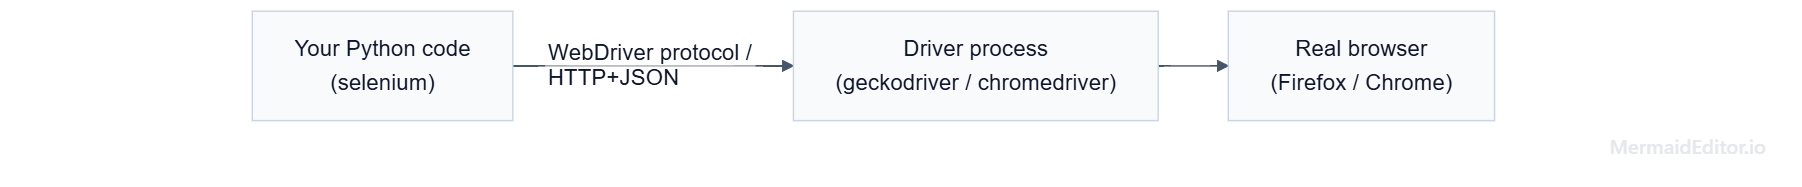
<!-- 
```
 Your Python code  ── (WebDriver protocol / HTTP+JSON)──▶  driver process  ──▶  real browser
   (selenium)                                            (geckodriver /       (Firefox / Chrome)
                                                            chromedriver)
``` -->
- **Browser** — the actual rendering engine (Firefox, Chrome, ...). This is what does the real work.
- **Driver** — a small server process that translates WebDriver commands ("click this", "find that
  element", "give me its text") into the browser's native automation protocol.
- **Selenium** (the Python package) — the client library that talks to the driver over HTTP.

To automate a browser you therefore need three things: the **browser itself**, its **driver**, and
the **selenium** Python package. Let's set all three up.


## 2. Environment setup

### 2.1 Classic way (manual driver download)

1. Install the browser itself (Firefox is recommended for this lab — it tends to be a little more
   forgiving with anti-bot fingerprinting than Chrome, though neither is bulletproof).
2. Download the matching **driver** binary:
   - Firefox → [`geckodriver`](https://github.com/mozilla/geckodriver/releases)
   - Chrome → [`chromedriver`](https://googlechromelabs.github.io/chrome-for-testing/)
3. Put the driver binary somewhere on your `PATH`, or pass its exact path in code.

### 2.2 Modern way — Selenium Manager (Selenium ≥ 4.6, *recommended*)

Since Selenium 4.6, calling `webdriver.Firefox()` or `webdriver.Chrome()` with **no arguments**
triggers **Selenium Manager**: it detects your installed browser version and silently downloads a
matching driver for you. For this lab, in most cases you can *skip step 2 and 3 above entirely* —
just make sure the browser is installed, and let Selenium handle the driver.

You only need to fall back to the manual approach if:
- you're behind a restrictive network/proxy that blocks the driver download,
- you need a specific driver version pinned for reproducibility, or
- Selenium Manager doesn't yet support your OS/browser combination.

| | Firefox | Chrome |
|---|---|---|
| Browser download | [mozilla.org/firefox](https://www.mozilla.org/firefox/new/) | [google.com/chrome](https://www.google.com/chrome/) |
| Driver | `geckodriver` (auto via Selenium Manager) | `chromedriver` (auto via Selenium Manager) |
| Headless flag | `-headless` | `--headless` |
| Notes | Strong W3C standard compliance; strict adherence to specs | Very well documented, huge community |


In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.firefox.options import Options as FirefoxOptions
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import (
    NoSuchElementException,
    ElementClickInterceptedException,
)

import time
import re
import pandas as pd

print("All imports OK")


All imports OK


## 3. Launching the browser: headed vs. headless

- **Headed** mode opens a real, visible browser window. Great for *debugging* — you can literally
  watch what your script does.
- **Headless** mode runs the same engine with no visible UI. It's faster, uses less memory, and is
  what you'd deploy on a server / in CI (no display available there anyway).

**Workflow tip:** develop headed (so you can *see* what's failing), then flip on headless once the
script works, for actual bulk crawling.

`Options` lets us configure the browser instance: headless mode, window size, a realistic
`User-Agent` string, disabling images to save bandwidth, etc.


In [5]:
def make_browser(headless: bool = True, browser = "firefox"):
    """Create a configured Firefox webdriver instance."""

    
    if browser=='firefox':
        
        opts = FirefoxOptions()
        if headless:
            opts.add_argument("-headless")

        # 1 (Allow all images to load, regardless of origin. (Default))
        # 2 (Block all images from loading.)
        # 3 (Prevent third-party images from loading.)
        opts.set_preference("permissions.default.image", 2)
        opts.add_argument("--width=1400")
        opts.add_argument("--height=1000")

        # A realistic UA reduces (but does not eliminate) the chance of being flagged as a bot.
        opts.set_preference(
            "general.useragent.override",
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36",
        )
        browser = webdriver.Firefox(options=opts)
    elif browser=='chrome':
        from selenium.webdriver.chrome.options import Options as ChromeOptions
        opts = ChromeOptions()
                
        if headless:
            opts.add_argument("--headless")
        opts.add_argument("--width=1400")
        opts.add_argument("--height=1000")
        
        # 2 blocks images; 1 allows them
        prefs = {"profile.managed_default_content_settings.images": 2}
        opts.add_experimental_option("prefs", prefs)
         
        # A realistic UA reduces (but does not eliminate) the chance of being flagged as a bot.
        opts.add_argument(f'--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36')
        browser = webdriver.Chrome(options=opts)
    else:
        raise ValueError(f"Unsupported browser: {browser}")

    browser.set_page_load_timeout(30) # 30 seconds

    return browser

# browser = make_browser(headless=False, browser = 'chrome')
browser = make_browser(headless=False, browser = 'firefox')
print("Browser session started:", browser.session_id)

Browser session started: 9682a637-fa16-4c67-834c-fc543f4b090f


In [97]:
# to close the headed browser 
# browser.close()

## 4. Waiting strategies: don't just `sleep()`

The page is rendered *asynchronously* — content pops in over time as JS runs and network requests
resolve. There are three ways to deal with this, in increasing order of robustness:

| Strategy | What it does | Problem |
|---|---|---|
| `time.sleep(n)` | Blindly pauses for `n` seconds | Wastes time when the page is fast, fails when it's slow — brittle |
| `browser.implicitly_wait(n)` | Tells the driver "for **every** `find_element` call, retry silently for up to `n` seconds before giving up" | Global, easy to misuse, doesn't wait for anything *specific* (e.g. "still loading" spinners) |
| `WebDriverWait(browser, n).until(EC.condition)` | (explicit wait) Polls until a **specific condition** is true (element present, clickable, visible, text changed...), then returns immediately | The right tool almost always — more code, but precise and fast |

A common mistake — worth calling out explicitly — is calling `implicitly_wait()` over and
over inside a loop, expecting it to "wait 5 seconds right now." It doesn't: it just sets a
(global) *ceiling* for future lookups. Prefer **explicit waits** tied to a real condition.

**Warning**: Do not mix implicit and explicit waits. Doing so can cause unpredictable wait times. For example, setting an implicit wait of 10 seconds and an explicit wait of 15 seconds could cause a timeout to occur after 20 seconds.

In [ ]:
url = "https://www.ozon.ru/category/smartfony-15502/"
url = "https://www.wildberries.ru/catalog/elektronika/smartfony-i-telefony/vse-smartfony"
url = "https://market.yandex.ru/category/mobilnyye-telefony"
browser.get(url)
# browser.implicitly_wait(5)
# browser.refresh()

# Explicit wait: block until at least one product card is present in the DOM,
# for AT MOST 20 seconds -- then continue immediately once it's there.
wait = WebDriverWait(browser, 20)

# MY_CSS_SELECTOR = "a._1OgMn"
MY_CSS_SELECTOR = ??
MY_XPATH = ??

wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, MY_CSS_SELECTOR)))
# wait.until(EC.presence_of_element_located((By.XPATH, MY_XPATH)))

print("Page title:", browser.title)
print("Current URL:", browser.current_url)
print("First link text:", browser.find_element(By.TAG_NAME, "a").text)
products = browser.find_elements(By.CSS_SELECTOR, MY_CSS_SELECTOR)
# products = browser.find_elements(By.XPATH, MY_XPATH)
if products and len(products)>0:
    
    for p in products:
        print("="*50)
        print("Current product card: \n", p.text.strip())
    print("="*50)
    print(f"Found {len(products)} products")
else:
    print("None")

Page title: Мобильные телефоны - купить по низкой цене на Яндекс Маркете
Current URL: https://market.yandex.ru/category/mobilnyye-telefony
First link text: Яндекс
Current product card: 
 ОРИГИНАЛ
Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (черный), 6000 мА*ч, IP64
Диагональ экрана: 6.78"
Встроенная память : 128 ГБ
Оперативная память: 8 ГБ
Версия: Ростест (EAC)
Количество основных камер: 1
Цена с картой Яндекс Пэй 15280 ₽ вместо
15 280
₽
Пэй
Рейтинг товара: 4.9 из 5
Оценок: (675) · 1.8K купили
4.9
(675) · 1.8K купили
11 – 13 сен
, 
ПВЗ
Курьер
TECNO STORE
В корзину
Current product card: 
 Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512GB Blue (MZB0MGURU) Ростест
Диагональ экрана: 6.77"
Встроенная память : 512 ГБ
Оперативная память: 12 ГБ
Версия: Ростест (EAC)
Количество основных камер: 2
Цена с картой Яндекс Пэй 34683 ₽ вместо
34 683
₽
Пэй
Рейтинг товара: 4.9 из 5
Оценок: (882) · 3.2K купили
4.9
(882) · 3.2K купили
11 – 13 сен
, 
ПВЗ
Курьер
В корзину
Current product card: 
 ОРИГИНАЛ
Смар

In [ ]:
# Refersh the page
# browser.refresh()

## 5. Locating elements: the `By` strategies

`selenium` mirrors `BeautifulSoup`'s idea of selectors, but works against the **live DOM** instead
of a static string of HTML.

| `By` strategy | Example | Notes |
|---|---|---|
| `By.ID` | `By.ID, "reload-button"` | Fastest, but requires a stable `id` attribute |
| `By.CLASS_NAME` | `By.CLASS_NAME, "product-card"` | Only one class name — fails on hyphenated/compound classes |
| `By.CSS_SELECTOR` | `By.CSS_SELECTOR, ".j4n_23 .tsBody500Medium"` | Most flexible for CSS-based sites; use this by default |
| `By.XPATH` | `By.XPATH, "//span[contains(text(),'отзывов')]"` | Needed when you must search by **text content** or walk **up** the tree |
| `By.TAG_NAME` | `By.TAG_NAME, "a"` | All elements of a tag, e.g. all links |
| `By.LINK_TEXT` / `By.PARTIAL_LINK_TEXT` | `By.PARTIAL_LINK_TEXT, "Следующая"` | Convenient for finding "Next"-style links by their visible text |

Two families of lookup methods:
- `find_element(...)` → the **first** match, raises `NoSuchElementException` if there is none.
- `find_elements(...)` → a **list** of all matches (empty list if none — never raises).

Auto-generated CSS classes on modern SPAs (like `.j4n_23`) are usually meaningless hashes that can
change between deployments — treat them as **fragile**, and prefer `data-*` attributes, `id`s, or
structural relationships (`parent > child`) when the site provides them.


In [ ]:
# Example: several ways to reach the same "product card" container.


# 1) by (fragile) auto-generated class name
MY_CSS_SELECTOR = ??
cards_by_class = browser.find_elements(By.CSS_SELECTOR, MY_CSS_SELECTOR)


MY_CSS_STRUCTURE_SELECTOR = ??
# 2) by tag + structural position (more robust to class renames, still fragile to layout changes)
cards_by_structure = browser.find_elements(By.CSS_SELECTOR, MY_CSS_STRUCTURE_SELECTOR)



# 3) by XPath, searching for a distinguishing piece of text
MY_XPATH = ??
cards_by_xpath = browser.find_elements(By.XPATH, MY_XPATH)
original_products = [ ]
for x in cards_by_xpath:
    try:
        found = x.find_element(By.XPATH, ??)
        original_products.append(x.text)
    except:
        pass


    
# original_labels  = browser.find_elements(By.XPATH, "//*[contains(translate(text(), 'ОРИГИНАЛ', 'оригинал'), 'оригинал')]")

print("cards found (class selector):", len(cards_by_class))
print("cards found (structure selector):", len(cards_by_structure))
print("cards found (xpath):", len(cards_by_xpath))
print("'ОРИГИНАЛ' products found:", len(original_products))
for x in cards_by_xpath:
    print("="*50)
    print(x.text)


cards found (class selector): 8
cards found (structure selector): 11
cards found (xpath): 11
'ОРИГИНАЛ' products found: 9
ОРИГИНАЛ
Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (черный), 6000 мА*ч, IP64
Диагональ экрана: 6.78"
Встроенная память : 128 ГБ
Оперативная память: 8 ГБ
Версия: Ростест (EAC)
Количество основных камер: 1
Цена с картой Яндекс Пэй 15280 ₽ вместо
15 280
₽
Пэй
Рейтинг товара: 4.9 из 5
Оценок: (675) · 1.8K купили
4.9
(675) · 1.8K купили
11 – 13 сен
, 
ПВЗ
Курьер
TECNO STORE
В корзину
Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512GB Blue (MZB0MGURU) Ростест
Диагональ экрана: 6.77"
Встроенная память : 512 ГБ
Оперативная память: 12 ГБ
Версия: Ростест (EAC)
Количество основных камер: 2
Цена с картой Яндекс Пэй 34683 ₽ вместо
34 683
₽
Пэй
Рейтинг товара: 4.9 из 5
Оценок: (882) · 3.2K купили
4.9
(882) · 3.2K купили
11 – 13 сен
, 
ПВЗ
Курьер
В корзину
ОРИГИНАЛ
Смартфон Realme Note 60x RMX3938 64Gb 3Gb черный
Диагональ экрана: 6.74"
Встроенная память : 64 ГБ
Оперативная память

### Relative XPath and Absolute XPath

XPath Syntax: https://www.w3schools.com/xml/xpath_syntax.asp

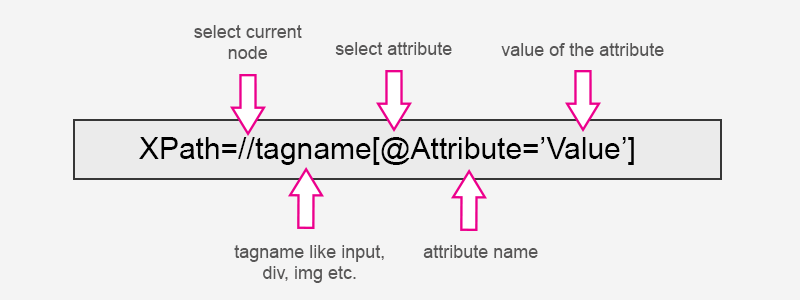

In [28]:
# The Common Mistake (Global Reset)
# This looks like it should only search inside the sidebar container...
sidebar = browser.find_element(By.ID, "searchFilters")

# BUT because of '//', Selenium resets and searches the GLOBAL DOM again!
buttons = sidebar.find_elements(By.XPATH, "//button") 

print(sidebar.text)
print("="*50)
print(f"{len(buttons)} buttons found.")

Войдите, и станет дешевле
В аккаунте больше скидок
Войти
Цена, ₽
От 835 ₽
До 564 919 ₽
Акции
Ниже рынка
Баллы за отзыв
Срок доставки
Экспресс
Сегодня
Сегодня‐завтра
До 3 дней
До 7 дней
Неважно
Сервис
ULTIMA
Проверено Маркетом
Оригинал
Лучшие находки
Спешл
Бренд
Apple
Samsung
Xiaomi
HONOR
realme
Показать всё
Состояние товара
Новый
Уценка
Линейка
Galaxy S
Galaxy A
Redmi Note
POCO
HONOR X
Ещё 72
Операционная система
Android
iOS
Series 60
HarmonyOS
BlackBerry OS
Ещё 2
Диагональ экрана, "
От 0 "
До 8 "
Тип корпуса
классический
сгибаемый
слайдер горизонтальный
раскладушка
ручка
Ещё 1
Разрешение экрана
1600x720
2340×1080
2400x1080
2532x1170
2556x1179
Ещё 77
Частота обновления экрана
60 Гц
90 Гц
120 Гц
144 Гц
165 Гц
Ещё 1
Встроенная память
64 ГБ
128 ГБ
256 ГБ
512 ГБ
1 ТБ
Ещё 8
Оперативная память
4 ГБ
6 ГБ
8 ГБ
12 ГБ
16 ГБ
Ещё 11
Беспроводные интерфейсы
Bluetooth
Wi-Fi
NFC
инфракрасный порт
Стандарт связи
2G
3G
4G LTE
5G
Разрешение основной камеры
менее 10 МП
10 - 14 МП
15 - 49 МП
50 - 99 МП
10

In [44]:
# The Correct Way (Scoped Relative Search)

sidebar = browser.find_element(By.ID, "searchFilters")

print(sidebar.text)
print("="*50)

# The dot (.) anchors the search relative to the parent 'sidebar' node
buttons = sidebar.find_elements(By.XPATH, ".//button") 
print(f"{len(buttons)} buttons found.")

buttons = sidebar.find_elements(By.TAG_NAME, "button") 
print(f"{len(buttons)} buttons found.")

buttons = browser.find_elements(By.TAG_NAME, "button") 
print(f"{len(buttons)} buttons found.")

Войдите, и станет дешевле
В аккаунте больше скидок
Войти
Цена, ₽
От 835 ₽
До 564 919 ₽
Акции
Ниже рынка
Баллы за отзыв
Срок доставки
Экспресс
Сегодня
Сегодня‐завтра
До 3 дней
До 7 дней
Неважно
Сервис
ULTIMA
Проверено Маркетом
Оригинал
Лучшие находки
Спешл
Бренд
Apple
Samsung
Xiaomi
HONOR
realme
Показать всё
Состояние товара
Новый
Уценка
Линейка
Galaxy S
Galaxy A
Redmi Note
POCO
HONOR X
Ещё 72
Операционная система
Android
iOS
Series 60
HarmonyOS
BlackBerry OS
Ещё 2
Диагональ экрана, "
От 0 "
До 8 "
Тип корпуса
классический
сгибаемый
слайдер горизонтальный
раскладушка
ручка
Ещё 1
Разрешение экрана
1600x720
2340×1080
2400x1080
2532x1170
2556x1179
Ещё 77
Частота обновления экрана
60 Гц
90 Гц
120 Гц
144 Гц
165 Гц
Ещё 1
Встроенная память
64 ГБ
128 ГБ
256 ГБ
512 ГБ
1 ТБ
Ещё 8
Оперативная память
4 ГБ
6 ГБ
8 ГБ
12 ГБ
16 ГБ
Ещё 11
Беспроводные интерфейсы
Bluetooth
Wi-Fi
NFC
инфракрасный порт
Стандарт связи
2G
3G
4G LTE
5G
Разрешение основной камеры
менее 10 МП
10 - 14 МП
15 - 49 МП
50 - 99 МП
10

## 6. Handling lazy-loaded content: scrolling

Infinite-scroll listings only render items as they enter (or approach) the viewport, to save
bandwidth. To collect everything, we simulate a user scrolling down repeatedly, giving the page a
moment to fetch/render new items after each scroll, and stopping once the page height stops
growing (a simple, general "stop condition" for infinite scroll).


### Scrolling via Jumping to Top/Bottom

In [ ]:
def scroll_to_load_all(browser, pause: float = 1.5, max_scrolls: int = 15):
    """Scroll to the bottom repeatedly until page height stabilizes or max_scrolls is hit."""
    last_height = browser.execute_script("return document.body.scrollHeight")
    for i in range(max_scrolls):

        # TODO: Scroll to the end.
        
        time.sleep(pause)
        
    else:
        print(f"Reached max_scrolls={max_scrolls}; page may still have more content")

scroll_to_load_all(browser)

cards = browser.find_elements(By.CSS_SELECTOR, MY_CSS_SELECTOR)
print("Total product cards after scrolling:", len(cards))


Stopped after 1 scroll(s); page height stable at 5458px
Total product cards after scrolling: 8


### Incremental scrolling

In [ ]:
def inc_scroll_to_load_all(browser, scroll_step=500, pause: float = 1.5, max_scrolls: int = 10):
    """Scroll incrementally scroll_step pixles each time until page height stabilizes or max_scrolls is hit."""

    browser.execute_script("window.scrollTo(0, 0);")
    
    last_height = 0
    for i in range(max_scrolls):
        
        # TODO: Scroll 500 pixels each time.

        time.sleep(pause)
    else:
        print(f"Reached max_scrolls={max_scrolls}; page may still have more content")

inc_scroll_to_load_all(browser)

cards = browser.find_elements(By.CSS_SELECTOR, MY_CSS_SELECTOR)
print("Total product cards after scrolling:", len(cards))


last height: 0
last height: 500
last height: 1000
last height: 1500
last height: 2000
last height: 2500
last height: 3000
last height: 3500
last height: 4000
last height: 4500
Reached max_scrolls=10; page may still have more content
Total product cards after scrolling: 24


In [81]:
browser.refresh()

## 7. Extracting structured data

Now the actual "information extraction" step. 

* for every product card, pull out the **title**,
**price**, and **rating / review-count**

**Note:** some cards are missing a rating — new products, no reviews yet. We also **clean** the raw text into numeric types right away, since downstream (ranking, filtering, indexing) code should never have to deal with `"10 030 ₽"` as a string.


In [102]:
MY_CSS_SELECTOR

'._1ENFO'

In [ ]:
def clean_price(text: str):
    """'10 030 ₽' -> 10030 (float). Returns None if no digits found."""
    digits = ??
    return float(digits) if digits else None

def clean_rating(text: str):
    """'4.9' -> 4.9. Returns None if not parseable."""
    
    m = ??
    if not m:
        return None
    
    rating = ??

    return rating

def clean_review(text: str):
    """' (22) · 202 купили' -> 22. Returns None if not parseable."""
    m = 
    
    if not m:
        return None
    reviews = ??
    return reviews

def scrape_listing_page(browser):
    records = []
    cards = browser.find_elements(By.CSS_SELECTOR, MY_CSS_SELECTOR)
    for card in cards:
        row = {"title": None, "price": None, "rating": None, "reviews": None}
        try:
            row["title"] = ??
        except NoSuchElementException:
            pass
        try:
            row["price"] = ??
        except NoSuchElementException:
            pass


        # TODO : do similarly for reviews and rating


        records.append(row)
    return records

records = scrape_listing_page(browser)
print(f"Scraped {len(records)} records from page 1")
print("Showing the first 10 products below")
print("="*50)
for r in records[:10]:
    print(r)


Scraped 24 records from page 1
Showing the first 10 products below
{'title': 'Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (черный), 6000 мА*ч, IP64', 'price': 15280, 'rating': 4.9, 'reviews': 675}
{'title': 'Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512GB Blue (MZB0MGURU) Ростест', 'price': 34683, 'rating': 4.9, 'reviews': 882}
{'title': 'Смартфон Realme Note 60x RMX3938 64Gb 3Gb черный', 'price': 9102, 'rating': 4.8, 'reviews': 93}
{'title': 'Смартфон HONOR X9d 12GB/256GB, AMOLED, 108MP, бежевый (5109BYPW)', 'price': 31644, 'rating': 4.9, 'reviews': None}
{'title': 'Смартфон OPPO A6 Pro 8/256, звездный синий', 'price': 24426, 'rating': 4.9, 'reviews': None}
{'title': 'Смартфон HONOR 600, 12ГБ/256 ГБ, Dual: nano SIM + eSIM, оранжевый', 'price': 46991, 'rating': 4.9, 'reviews': 239}
{'title': 'Смартфон Samsung Galaxy A17 8/256 ГБ, 6.7", 2340x1080, Super AMOLED, 90 Гц, черный', 'price': 19590, 'rating': 4.9, 'reviews': 14}
{'title': 'Детский умный телефон ELARI GamePhone с развивающим к

In [72]:
df = pd.DataFrame(records)
print(df.shape)
df.head(8)


(24, 4)


,title,price,rating,reviews
0,"Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (...",15280,4.9,675.0
1,Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512G...,34683,4.9,882.0
2,Смартфон Realme Note 60x RMX3938 64Gb 3Gb черный,9102,4.8,93.0
3,"Смартфон HONOR X9d 12GB/256GB, AMOLED, 108MP, ...",31644,4.9,NaN
4,"Смартфон OPPO A6 Pro 8/256, звездный синий",24426,4.9,NaN
5,"Смартфон HONOR 600, 12ГБ/256 ГБ, Dual: nano SI...",46991,4.9,239.0
6,"Смартфон Samsung Galaxy A17 8/256 ГБ, 6.7"", 23...",19590,4.9,14.0
7,Детский умный телефон ELARI GamePhone с развив...,3673,4.0,4.0


In [73]:
df.describe(include="all")


,title,price,rating,reviews
count,24,24.000000,24.000000,15.000000
unique,24,NaN,NaN,NaN
top,"Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (...",NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,29448.500000,4.783333,253.533333
std,NaN,27109.090373,0.246129,335.750304
min,NaN,3673.000000,4.000000,4.000000
25%,NaN,15940.000000,4.800000,20.500000
50%,NaN,24913.500000,4.900000,56.000000
75%,NaN,35071.750000,4.900000,444.500000


## 8. Pagination: growing the crawl frontier

In IR terms, each "next page" link is an **outlink** we choose to follow — a miniature crawl
frontier. Two crawling principles apply even at this tiny scale:

- **Politeness**: sleep between requests, don't hammer the server.
- **Bounded scope**: decide up-front how deep/wide to crawl (`n_pages` below) — real crawlers use
  budgets, priority queues, and duplicate-URL filters for exactly this reason.


In [ ]:
def crawl_n_pages(browser, n_pages: int = 3, delay: float = 2.0):
    all_records = []
    for page_num in range(1, n_pages + 1):
        wait.until(EC.presence_of_element_located((By.XPATH, MY_XPATH)))
        scroll_to_load_all(browser, pause=1.0, max_scrolls=6)
        page_records = scrape_listing_page(browser)
        for r in page_records:
            r["page"] = page_num
        all_records.extend(page_records)
        print(f"Page {page_num}: {len(page_records)} records (running total: {len(all_records)})")

        if page_num == n_pages:
            break
        try:
            next_link = browser.find_element(By.LINK_TEXT, "Вперёд")
            next_link.click()
        except (NoSuchElementException, ElementClickInterceptedException):
            print("No further 'next' button found -- stopping early.")
            break
        time.sleep(delay)  # politeness: don't hammer the server
    return all_records

all_records = crawl_n_pages(browser, n_pages=3)
df_all = pd.DataFrame(all_records)
print(df_all.shape)


Stopped after 1 scroll(s); page height stable at 127135px
Page 1: 456 records (running total: 456)
No further 'next' button found -- stopping early.
(456, 5)


In [75]:
df_all

,title,price,rating,reviews,page
0,"Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (...",15280,4.9,675.0,1
1,Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512G...,34683,4.9,882.0,1
2,Смартфон Realme Note 60x RMX3938 64Gb 3Gb черный,9102,4.8,93.0,1
3,"Смартфон HONOR X9d 12GB/256GB, AMOLED, 108MP, ...",31644,4.9,NaN,1
4,"Смартфон OPPO A6 Pro 8/256, звездный синий",24426,4.9,NaN,1
...,...,...,...,...,...
451,"Смартфон Infinix Note 50, 8ГБ/256ГБ, 4G, Dual ...",37469,NaN,NaN,1
452,Смартфон iPhone 17 Pro Max 512Gb Deep Blue E-Sim,141395,5.0,16.0,1
453,"Смартфон Honor 600 12/256 Gb, 120 Гц, цвет Bla...",50928,NaN,NaN,1
454,Apple iPhone 17 Pro Max 256Gb Sim+eSim Blue (G...,137454,5.0,255.0,1


## 9. Following links: scraping a product's detail page

Listing pages give us a *summary*; detail pages give us the *document itself* — the full
description text a search engine would actually index. Let's navigate into the very first product
and pull its "About the product" (**О товаре**) block.


In [ ]:
first_card = ??
product_link = ??
product_url = product_link.get_attribute("href")
print("Following link to:", product_url)

# Execute this to open the page on the same tab/window
browser.execute_script("arguments[0].removeAttribute('target');", product_link)

# Go to the product page
product_link.click()

MY_DESC_XPATH = ??
MY_DESC_CSS_SELECTOR = ??

wait.until(EC.presence_of_element_located((By.XPATH, MY_DESC_XPATH)))

about_block = browser.find_element(By.CSS_SELECTOR, MY_DESC_CSS_SELECTOR)
print("--- About the product (first 400 chars) ---")
print(about_block.text[:400])

browser.back()  # return to the listing so the crawl loop can continue cleanly


Following link to: https://market.yandex.ru/card/smartfon-tecno-pova-7-5g-8gb128gb-chernyy-geek-black/4718788029?do-waremd5=RSoz3ZhY2mONS3ORCcm28A&sponsored=1&cpc=Xk-u9u8LwrsRaa3jDI4pgHfnjJWDF4FzUrXTY_kNCqVkeFS_AobR5f4BTf9aq34Y8M7q2crpm_CkqI9RIxcmE7NCtdg4LtWOTZfOnupo8p2bB8iaX6StnWNpYApD9bpXVPseBJ5eudK4i3oFduwfm-uSxEP0I1IxCg4hFAhxvKMEBdzUo8P4EcLMik7MW3TneF7zsyvyyRy17uBX_AjPbVY70-P0oXzFCuIA8ajsMzuf9eCogw0QQ1K7K19kDYNjfjIZRzApcLXTEHBlQiqlhbLgjUdhazGehCloVPDFRrxnP4Q1i2hEuwMbbTlYgeqQVm7mCN6hnoXKOflcre7VkHKTey0RR1yiKwzk9YWZTk4rzNxWJinat9_eAoyb2dZWIYKhaLknfqQ4Bd6XqlQPVummbt4l2mdC0SG2uC33Oaryza_2cmWSoJvN5zj-A_SUbrtKA6iIC1mwN0TiZOGAkqufoi7AFZJBqW7k4Y7AuVJg6whBkAHZgV7PLrPPmhalpDPEQ1YdVDR_DQYG6aBm1TTjJl9hGHxwQ4ce69dhaxr1QruBFxzEfsFIQjGcIrbv&cc=CiA2YzgyYmI3YWM1OWMyY2IxODNiMDk5MWVjYTUyYzRlNRDnAYB95u0G&resale_goods=resale_new&hid=91491&nid=34512430&show-uid=17889040886992850346406001&showUid=17889040886992850346406001&from-show-uid=17889040886992850346406001&cpa=1
--- About the product (first 400 ch

## 10. Persisting the crawl

Always write the raw crawl to disk before doing anything fancier — tokenizing, indexing, ranking.
If a later step in your pipeline crashes, you don't want to have to re-crawl.


In [115]:
OUTPUT_PATH = "collected_smartphones.csv"
df_all.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Saved {len(df_all)} rows to {OUTPUT_PATH}")


Saved 456 rows to collected_smartphones.csv


In [ ]:
browser.quit()
print("Browser session closed.")


Browser session closed.


**Always call `.quit()`** (not just closing the window) when you're done — it releases the
driver process and any temporary profile directories. Forgetting this is the #1 cause of
"why do I have 40 zombie `geckodriver` processes eating my RAM" during scraping labs. A
`try/finally` (or a context-manager wrapper) around your crawl loop is a good habit:

```python
browser = make_browser(headless=True)
try:
    ...  # your crawl
finally:
    browser.quit()
```


## 11. Common exceptions & how to react to them

| Exception | Typical cause | What to do |
|---|---|---|
| `NoSuchElementException` | Selector doesn't match anything *right now* | Wrap in `try/except`; treat as "field missing", not a crash |
| `TimeoutException` | `WebDriverWait` condition never became true within the timeout | Increase timeout, double-check the selector, check if you got blocked/redirected |
| `StaleElementReferenceException` | The DOM element you're holding was removed/replaced (e.g. after a re-render) | Re-`find_element` right before using it; don't cache elements across page changes |
| `ElementClickInterceptedException` | Something (a cookie banner, an overlay) is covering the element | Dismiss the overlay first, or scroll the element into view before clicking |
| `WebDriverException: session not created` | Driver / browser version mismatch | Let Selenium Manager handle it, or update the driver manually |

A good default pattern for any single field extraction:

```python
try:
    value = element.find_element(By.CSS_SELECTOR, ".some-class").text
except NoSuchElementException:
    value = None
```

...rather than a bare `except:` (as tempting as it is) — a bare `except` will also silently
swallow real bugs (typos in your own code!), not just "element missing."


## 12. Politeness, `robots.txt`, and crawling ethics

Before crawling *any* site at scale:

1. **Check `robots.txt`** (e.g. `https://www.ozon.ru/robots.txt`) for `Disallow` rules and a
   `Crawl-delay` directive.
2. **Read the Terms of Service** — `robots.txt` is a technical courtesy, not a legal shield; ToS
   may separately prohibit automated access regardless of what `robots.txt` says.
3. **Rate-limit yourself** — add delays, don't parallelize into a denial-of-service.
4. **Identify yourself** where reasonable (a descriptive `User-Agent`), for non-adversarial crawls.
5. **Cache & dedupe** — don't re-fetch pages you already have; canonicalize URLs to avoid crawling
   the same document under ten different query-string variants.
6. **Personal data** — scraped listings are often *public* commercial data, but be careful the
   moment any personal data (reviews with names, phone numbers, etc.) enters your dataset.

These aren't just legal/ethical checkboxes — they're the same concerns a production **crawler
politeness policy** encodes (this is standard IR curriculum: see Manning et al., *Introduction to
Information Retrieval*, ch. 20, on crawling architecture, freshness, and politeness).


In [117]:
from urllib import robotparser

url = "https://market.yandex.ru/category/mobilnyye-telefony"

rp = robotparser.RobotFileParser()
rp.set_url("https://market.yandex.ru/robots.txt")
rp.read()

test_url = url
print("Allowed for '*':", rp.can_fetch("*", test_url))
crawl_delay = rp.crawl_delay("*")
print("Crawl-delay for '*':", crawl_delay)


Allowed for '*': False
Crawl-delay for '*': None


## 13. a mini inverted index over the crawl

We now have documents (product titles). Let's do the very first thing an IR system does with new
documents: **tokenize** and build an **inverted index** (`term -> {doc_ids containing term}`), and
run a toy boolean AND query against it — connecting this crawling lab back to the indexing labs
elsewhere in the course.


In [118]:
df_all

,title,price,rating,reviews,page
0,"Смартфон Tecno POVA 7 5G 8/128ГБ, Geek Black (...",15280,4.9,675.0,1
1,Смартфон Xiaomi REDMI Note 15 Pro 4G 12GB+512G...,34683,4.9,882.0,1
2,Смартфон Realme Note 60x RMX3938 64Gb 3Gb черный,9102,4.8,93.0,1
3,"Смартфон HONOR X9d 12GB/256GB, AMOLED, 108MP, ...",31644,4.9,NaN,1
4,"Смартфон OPPO A6 Pro 8/256, звездный синий",24426,4.9,NaN,1
...,...,...,...,...,...
451,"Смартфон Infinix Note 50, 8ГБ/256ГБ, 4G, Dual ...",37469,NaN,NaN,1
452,Смартфон iPhone 17 Pro Max 512Gb Deep Blue E-Sim,141395,5.0,16.0,1
453,"Смартфон Honor 600 12/256 Gb, 120 Гц, цвет Bla...",50928,NaN,NaN,1
454,Apple iPhone 17 Pro Max 256Gb Sim+eSim Blue (G...,137454,5.0,255.0,1


In [ ]:
def tokenize(text: str):
    text = text.lower()
    text = ?? # Replace non-space or non-words with spaces
    return [tok for tok in text.split() if tok]

def build_inverted_index(titles):
    index = {}

    # TODO: build index = {"token1": {doc1_id, doc2_id,...}, "token2": {doc1_id, ...}, ...}
    
    return index

titles = df_all["title"].dropna().tolist()
index = build_inverted_index(titles)

print("Vocabulary size:", len(index))
print("Postings for 'xiaomi':", sorted(index.get("xiaomi", [])))
print("Postings for '256':", sorted(index.get("256", [])))

def boolean_and_query(index, terms, titles):
    terms = [t.lower() for t in terms]
    if not terms or terms[0] not in index:
        return []

    result = set(index[terms[0]])

    # TODO: you need to get the list of common document ids between all query terms 

    return [(doc_id, titles[doc_id]) for doc_id in sorted(result)]

hits = boolean_and_query(index, ["xiaomi", "256"], titles)
print(f"\n'xiaomi AND 256' -> {len(hits)} hits")
for doc_id, title in hits[:5]:
    print(f"  [{doc_id}] {title}")


Vocabulary size: 569
Postings for 'xiaomi': [1, 8, 23, 28, 45, 68, 78, 88, 90, 92, 102, 135, 136, 145, 175, 182, 183, 189, 192, 193, 196, 200, 207, 208, 209, 210, 226, 228, 235, 242, 266, 271, 293, 298, 314, 323, 333, 352, 363, 381, 407, 412, 417, 426]
Postings for '256': [4, 5, 6, 9, 17, 19, 20, 22, 23, 25, 28, 31, 32, 37, 40, 41, 44, 50, 52, 60, 65, 66, 69, 91, 93, 95, 97, 102, 104, 108, 109, 110, 116, 121, 124, 126, 128, 133, 147, 151, 153, 156, 161, 162, 166, 167, 170, 181, 185, 190, 194, 195, 203, 205, 206, 212, 216, 217, 225, 227, 233, 236, 237, 238, 239, 244, 245, 268, 270, 271, 273, 275, 276, 279, 282, 289, 294, 299, 302, 303, 307, 310, 311, 325, 332, 334, 335, 338, 346, 350, 358, 372, 373, 374, 383, 384, 385, 387, 390, 392, 394, 395, 396, 405, 406, 410, 414, 419, 421, 424, 427, 431, 436, 443, 444, 445, 447, 448, 453]

'xiaomi AND 256' -> 4 hits
  [23] Смартфон Xiaomi Redmi Note 14s 8/256 ГБ Ростест (EAC), Dual nano SIM, Midnight Black
  [28] Смартфон Xiaomi Redmi Note 15 Pro 5

## 14. Exercises

Work through these in order; each builds on code already defined above.

### Exercise 1 — New category
Pick a different Yandex.Market category URL (e.g. laptops, headphones) and re-run `scrape_listing_page`
against it. Confirm your selectors still work — **do they?** Auto-generated classes like `.j4n_23`
are notoriously unstable across categories/deployments; if they don't match, use your browser's
DevTools ("Inspect Element") to find the current class names and update the constants.

### Exercise 2 — Deeper pagination
Extend `crawl_n_pages` to collect **5** pages instead of 3, and report:
- total records collected,
- how many had a missing rating (`rating is None`),
- the 5 cheapest and 5 most expensive products by `price`.

### Exercise 3 — Detail-page crawl (from the original lab)
- Navigate to page 2 of the listing.
- Select the **first** product on that page.
- Print its full "About the product" (**О товаре**) text.

### Exercise 4 — Robustness
Deliberately break one selector (e.g. change `.tsBody500Medium` to a nonsense class name) and
re-run the scraper. Confirm it **doesn't crash** — it should just report `title: None` for every
row. Explain in a markdown cell *why* defensive `try/except` per-field (Section 7) is safer than
one big `try/except` around the whole record.

### Exercise 5 — Mini search engine (bonus, ties into indexing/ranking labs)
Using the inverted index from Section 13:
1. Add a simple **ranking** on top of boolean retrieval: for a query with multiple AND'd terms,
   rank matching titles by `price` ascending (cheapest first).
2. Extend tokenization to strip common stopword-like tokens for this domain (`смартфон`, `гб`, `ростест`, `eac`, ...) and rebuild the index. Does vocabulary size shrink meaningfully?
3. (Stretch) Compute simple TF weighting per document instead of a boolean index, and rank by
   number of matched query terms.

### Exercise 6 — Politeness in practice
Wrap your crawl loop so that it: checks `robots.txt` **before** crawling a URL, respects any
`Crawl-delay`, and skips (with a printed warning) any URL that's disallowed.


## 15. Summary

- Static fetch (`requests`) fails silently on JS-rendered SPAs — you get HTML shell/skeleton, not the data.
- **Selenium** drives a real browser (via a driver process) so JavaScript actually executes.
- Prefer **Selenium Manager** (`webdriver.Firefox()` / `webdriver.Chrome()`, Selenium ≥ 4.6) over
  manually downloading drivers.
- Use explicit waits (`WebDriverWait` + `expected_conditions`) instead of blind `sleep()` or
  repeated `implicitly_wait()` calls.
- `By.CSS_SELECTOR` and `By.XPATH` cover almost every real-world case; auto-generated class names
  are fragile — verify them per site/category.
- Handle infinite scroll by scrolling until page height stabilizes.
- Extract data field by field, with `try/except NoSuchElementException` — don't let one
  missing rating kill the whole record.
- Clean text into numeric types (`price`, `rating`) at scrape time, not later.
- Pagination = a tiny **crawl frontier**; always bound it and add delays (**politeness**).
- Always `browser.quit()`.
- Crawling is step 1 of the IR pipeline — everything else (tokenize → index → rank) depends on
  getting *clean, complete documents* out of this step.

## References

- Selenium documentation: <https://www.selenium.dev/documentation/>
- Selenium Manager: <https://www.selenium.dev/documentation/selenium_manager/>
- `geckodriver` releases: <https://github.com/mozilla/geckodriver/releases>
- MDN, HTTP 403: <https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403>
- `robots.txt` spec (RFC 9309): <https://www.rfc-editor.org/rfc/rfc9309>
- Manning, Raghavan, Schütze — *Introduction to Information Retrieval*, Ch. 20 (Web crawling and indexes): <https://nlp.stanford.edu/IR-book/>
